**Byte pair encoding (BPE)** is an algorithm that learns useful pieces of text by repeatedly combining the most frequent neighboring pair of tokens. A tokenizer assigns these pieces integer IDs, turning text into a sequence of numbers that a language model can process.

Think of text as a row of small building blocks. If two blocks often appear next to each other, we create a larger block that represents both. That new block can later combine with another block, allowing us to build up longer recurring patterns. The collection of available blocks is our **vocabulary**.

In this notebook, the smallest blocks are **UTF-8 bytes**. We start with 256 base tokens, one for each possible byte value. A letter such as `a` occupies one byte; many other characters, including emoji, occupy several. Each learned token represents a sequence of these original bytes.

**Training BPE** means learning which blocks to combine:

1. Convert the training text into a sequence of byte tokens.
2. Count neighboring token pairs and choose the most frequent pair.
3. Give that pair a new token ID and replace its non-overlapping occurrences with the new token. Save the rule.
4. Count again in the updated sequence and repeat until we reach the chosen vocabulary size.

For a small example, imagine our training text is `ababab`. Each bracket below represents one token:

```text
Start:           [a] [b] [a] [b] [a] [b]   6 tokens
Merge a + b:     [ab] [ab] [ab]             3 tokens
Merge ab + ab:   [abab] [ab]                2 tokens
```

The text still says `ababab`; we have changed how we represent it. Each new piece gets its own ID, such as `256` for `ab` and `257` for `abab`. The final sequence would then be `[257, 256]`. The vocabulary has grown by two tokens, while the sequence needed to represent this text has become shorter.

Once training is complete, **encoding** applies the learned merge rules to new text in their learned priority order. **Decoding** looks up the bytes represented by each token ID, joins them, and converts the result back to text.

Two dictionaries will help us do this: `merges` remembers **which pair becomes which new token**, and `vocab` remembers **which bytes each token represents**. We will build them step by step, then check that encoding and decoding recover the original text.

**BPE was also used in GPT-2.** The original GPT-2 paper, [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) (Radford et al., 2019), describes a version of BPE that operates on bytes.

For more insight into these tokenization choices, read **Section 2.2, “Input Representation” (page 4)**. It explains why starting with 256 byte values allows the tokenizer to represent Unicode text, while learned merges give frequent sequences their own tokens.

Our notebook demonstrates the core idea. GPT-2 adds rules that limit merges across character categories, with an exception for spaces. The paper is a useful next step for understanding how this simple algorithm is adapted for a language model.

In [1]:
# Original Shakespeare-inspired fiction with mixed Unicode characters.
initial_text = """THE MOONLIT MASQUE 🌙🎭
[Enter LYSANDER and MIRABEL beneath a silver willow.]

LYSANDER: What light hath taught these midnight leaves to sing? 🌙
MIRABEL: Thy lantern wakes the roses, gentle fool. 🌹
FOOL: Then write thy vows in ＬＯＶＥ and 🅛🅞🅥🅔 alike;
      a gilded letter cannot mend a broken promise.
LYSANDER: “My heart is thine”—yet how shall ink hold thunder?
CHORUS: Speak softly, heart; the night remembers all. ✨"""
tokens = initial_text.encode("utf-8") # raw bytes

In [2]:
tokens = initial_text.encode("utf-8") # UTF-8 encodes a character as one or more bytes.

In [3]:
tokens = list(map(int, tokens))  # Byte values become our initial token IDs (0-255).

In [4]:
# String length counts Unicode code points.
print(initial_text, f"\n --> has length is {len(initial_text)}")


THE MOONLIT MASQUE 🌙🎭
[Enter LYSANDER and MIRABEL beneath a silver willow.]

LYSANDER: What light hath taught these midnight leaves to sing? 🌙
MIRABEL: Thy lantern wakes the roses, gentle fool. 🌹
FOOL: Then write thy vows in ＬＯＶＥ and 🅛🅞🅥🅔 alike;
      a gilded letter cannot mend a broken promise.
LYSANDER: “My heart is thine”—yet how shall ink hold thunder?
CHORUS: Speak softly, heart; the night remembers all. ✨ 
 --> has length is 415


In [5]:
# At this stage, the token count equals the byte count.
print(tokens, f"\n --> has length is {len(tokens)}")

[84, 72, 69, 32, 77, 79, 79, 78, 76, 73, 84, 32, 77, 65, 83, 81, 85, 69, 32, 240, 159, 140, 153, 240, 159, 142, 173, 10, 91, 69, 110, 116, 101, 114, 32, 76, 89, 83, 65, 78, 68, 69, 82, 32, 97, 110, 100, 32, 77, 73, 82, 65, 66, 69, 76, 32, 98, 101, 110, 101, 97, 116, 104, 32, 97, 32, 115, 105, 108, 118, 101, 114, 32, 119, 105, 108, 108, 111, 119, 46, 93, 10, 10, 76, 89, 83, 65, 78, 68, 69, 82, 58, 32, 87, 104, 97, 116, 32, 108, 105, 103, 104, 116, 32, 104, 97, 116, 104, 32, 116, 97, 117, 103, 104, 116, 32, 116, 104, 101, 115, 101, 32, 109, 105, 100, 110, 105, 103, 104, 116, 32, 108, 101, 97, 118, 101, 115, 32, 116, 111, 32, 115, 105, 110, 103, 63, 32, 240, 159, 140, 153, 10, 77, 73, 82, 65, 66, 69, 76, 58, 32, 84, 104, 121, 32, 108, 97, 110, 116, 101, 114, 110, 32, 119, 97, 107, 101, 115, 32, 116, 104, 101, 32, 114, 111, 115, 101, 115, 44, 32, 103, 101, 110, 116, 108, 101, 32, 102, 111, 111, 108, 46, 32, 240, 159, 140, 185, 10, 70, 79, 79, 76, 58, 32, 84, 104, 101, 110, 32, 119, 114, 10

In [6]:
def get_stats(token_ids):
    counts = {}
    for token_pair in zip(token_ids, token_ids[1:]): # Visit neighboring pairs, including overlaps.
        counts[token_pair] = counts.get(token_pair, 0) + 1
    return counts

stats = get_stats(tokens)

The `get_stats(token_ids)` function **counts how often each pair of neighboring tokens appears** in a sequence. Here, `token_ids` is the function's name for the list passed to it as `tokens`.

For example, suppose the input is:

```python
tokens = [1, 2, 1, 2, 3]
```

1. **`counts = {}`** creates an empty dictionary to store each pair and its count.

2. **`zip(token_ids, token_ids[1:])`** pairs each element with the next element. `token_ids[1:]` means everything from index 1 onward:

   ```text
   token_ids:      1  2  1  2  3
   token_ids[1:]:  2  1  2  3
   pairs:         (1,2), (2,1), (1,2), (2,3)
   ```

   `zip` stops when the shorter sequence runs out. The pairs overlap: each interior token belongs to two neighboring pairs.

3. **`counts[token_pair] = counts.get(token_pair, 0) + 1`** increases that pair's count. `counts.get(token_pair, 0)` retrieves its existing count, or `0` if it has not appeared yet. Adding `1` counts the current occurrence.

4. **`return counts`** returns the completed dictionary.

Calling the function with the example input:

```python
stats = get_stats(tokens)
print(stats)
```

produces:

```python
{(1, 2): 2, (2, 1): 1, (2, 3): 1}
```

The pair `(1, 2)` occurs twice; the other pairs occur once.

In [7]:
top_pair = max(stats, key=stats.get)  # Choose the pair with the highest count.
top_pair

(240, 159)

In [8]:
def merge(token_ids, token_pair, new_token_id):
  # Replace matching pairs from left to right.
  merged_token_ids = []
  i = 0
  while i < len(token_ids):
    # Make sure a next token exists before checking the pair.
    if i < len(token_ids) - 1 and token_ids[i] == token_pair[0] and token_ids[i+1] == token_pair[1]:
      merged_token_ids.append(new_token_id)
      i += 2  # Both input tokens have been consumed.
    else:
      merged_token_ids.append(token_ids[i])
      i += 1
  return merged_token_ids

print(merge([5, 6, 6, 7, 9, 1], (6, 7), 99))

tokens2 = merge(tokens, top_pair, 256)  # 256 is the first ID beyond the byte tokens.
print(tokens2)
print("length:", len(tokens2))

[5, 6, 99, 9, 1]
[84, 72, 69, 32, 77, 79, 79, 78, 76, 73, 84, 32, 77, 65, 83, 81, 85, 69, 32, 256, 140, 153, 256, 142, 173, 10, 91, 69, 110, 116, 101, 114, 32, 76, 89, 83, 65, 78, 68, 69, 82, 32, 97, 110, 100, 32, 77, 73, 82, 65, 66, 69, 76, 32, 98, 101, 110, 101, 97, 116, 104, 32, 97, 32, 115, 105, 108, 118, 101, 114, 32, 119, 105, 108, 108, 111, 119, 46, 93, 10, 10, 76, 89, 83, 65, 78, 68, 69, 82, 58, 32, 87, 104, 97, 116, 32, 108, 105, 103, 104, 116, 32, 104, 97, 116, 104, 32, 116, 97, 117, 103, 104, 116, 32, 116, 104, 101, 115, 101, 32, 109, 105, 100, 110, 105, 103, 104, 116, 32, 108, 101, 97, 118, 101, 115, 32, 116, 111, 32, 115, 105, 110, 103, 63, 32, 256, 140, 153, 10, 77, 73, 82, 65, 66, 69, 76, 58, 32, 84, 104, 121, 32, 108, 97, 110, 116, 101, 114, 110, 32, 119, 97, 107, 101, 115, 32, 116, 104, 101, 32, 114, 111, 115, 101, 115, 44, 32, 103, 101, 110, 116, 108, 101, 32, 102, 111, 111, 108, 46, 32, 256, 140, 185, 10, 70, 79, 79, 76, 58, 32, 84, 104, 101, 110, 32, 119, 114, 105, 

The `merge(token_ids, token_pair, new_token_id)` function **replaces matching neighboring token pairs with a single token ID**. It scans the input from left to right and builds a new list. Each replacement reduces the sequence length by one.

Its three inputs are:

- `token_ids`: the current list of token IDs.
- `token_pair`: the two token IDs to look for, in order.
- `new_token_id`: the token ID that will represent that pair. We choose an unused ID when adding a token to our vocabulary.

Using the example in the code cell:

```python
merge([5, 6, 6, 7, 9, 1], (6, 7), 99)
# Result: [5, 6, 99, 9, 1]
```

Here, `99` is an illustrative ID for the pair `(6, 7)`. The first `6` stays because its next neighbor is another `6`. The second `6` is followed by `7`, so those two tokens become `99`.

The loop works as follows:

1. **`merged_token_ids = []` and `i = 0`** create the output list and start at the first input position.

2. **`while i < len(token_ids)`** keeps scanning until every input token has been processed.

3. **The `if` condition checks for a matching pair.** `i < len(token_ids) - 1` checks that a next token exists. Python evaluates `and` from left to right and stops at a false condition, so it only checks `token_ids[i+1]` when that position exists. The remaining conditions compare the current and next tokens with `token_pair[0]` and `token_pair[1]`.

4. **When the pair matches**, `merged_token_ids.append(new_token_id)` adds the replacement token. `i += 2` moves past both input tokens because both have been consumed.

5. **When there is no match**, `merged_token_ids.append(token_ids[i])` copies the current token. `i += 1` advances to the next position. This also handles a final token with no neighbor.

6. **`return merged_token_ids`** returns the new sequence. The original input list is unchanged.

Tracing the example makes the two ways of advancing easier to see:

| Position `i` | Tokens checked | Action | Output so far |
| --- | --- | --- | --- |
| 0 | `(5, 6)` | Copy `5`; advance by 1 | `[5]` |
| 1 | `(6, 6)` | Copy `6`; advance by 1 | `[5, 6]` |
| 2 | `(6, 7)` | Add `99`; advance by 2 | `[5, 6, 99]` |
| 4 | `(9, 1)` | Copy `9`; advance by 1 | `[5, 6, 99, 9]` |
| 5 | Last token: `1` | Copy `1`; advance by 1 | `[5, 6, 99, 9, 1]` |

**Merges cannot overlap.** For example, `merge([6, 6, 6], (6, 6), 99)` returns `[99, 6]`. The first two tokens are consumed together, leaving the third token on its own. Although `get_stats` counts two overlapping occurrences of `(6, 6)` here, only one replacement is possible.

In our tokenizer, `get_stats` counts the neighboring pairs and `top_pair = max(stats, key=stats.get)` selects the most frequent one. Then:

```python
tokens2 = merge(tokens, top_pair, 256)
```

replaces each non-overlapping occurrence of that pair with token ID `256`. Our initial byte IDs range from `0` to `255`, so `256` is the first available ID for a new token. Repeating the steps of counting, selecting, and merging is the basic training loop of **byte pair encoding (BPE)**. To decode the new IDs later, we also need to record which pair each new token represents.

In [9]:
# Extend the opening scene; repeated voices and refrains give BPE patterns to learn.
# The two spellings of café below deliberately use different Unicode sequences.
extended_text = initial_text + """

ACT I — THE GATE OF MANY LETTERS 🏰

[A bell rings. The gatekeeper unfolds a banner: 🅤🅝🅘🅒🅞🅓🅔.]

GATEKEEPER: Who comes so late, when honest clocks are sleeping?
LYSANDER: Two travellers, one lantern, and a question.
MIRABEL: Three questions, sir; he hath forgotten mine.
FOOL: And one unpaid account for bread and honey. 🍞🍯

GATEKEEPER: The queen admits all letters to her revel:
           the tall, the small, the crooked, and the crowned.
           Here LOVE may dance with ＬＯＶＥ in the courtyard,
           while 🅛🅞🅥🅔 leans laughing from the balcony.
           But names must be remembered as they entered;
           our scribes shall lose no mark upon the road.

MIRABEL: Then keep my name as carefully as my promise.
LYSANDER: And keep my promise better than my purse.
FOOL: A prudent order! Promises weigh nothing,
      yet cost a kingdom when the bill arrives.

[The gate opens. Lanterns drift above the crowd. 🏮🏮🏮]
CHORUS: Speak softly, heart; the night remembers all. ✨

ACT II — THE SCRIBE AND THE TWO CUPS ☕

[At a little table, a SCRIBE labels cups for the guests.]

SCRIBE: Here is “café”, written by the master;
        here is “café”, written by the apprentice.
        To hurried eyes, the names may look the same.
        Yet one bears its accent within the letter,
        and one receives the accent afterward.

FOOL: Then serve me both, and let my tongue decide!
MIRABEL: Thy tongue would vote for any cup with sugar.
LYSANDER: Can two fair faces hide two different journeys?
SCRIBE: Indeed. A faithful scribe preserves the footsteps,
        even when the travellers reach one door.

MIRABEL: Write “naïve” upon the poet's empty cup,
         and “déjà vu” upon the fool's third helping.
FOOL: Write “paid” upon them all; that word is sweetest.

[A cat examines the ink, then signs the ledger with a paw. 🐈🐾]
SCRIBE: This signature is neither prince nor merchant.
FOOL: Yet plainly one who means to own the table.

CHORUS: Speak softly, heart; the night remembers all. ✨

ACT III — A LETTER IN THE ORCHARD 🌳💌

[MIRABEL finds a folded letter beneath a pear tree.]

MIRABEL: “Meet me where the moonlight meets the water.”
         No name, no seal, no hour! A generous puzzle.
LYSANDER: I wrote it when the bells forgot their numbers.
MIRABEL: The bells forget less often than their poet.

LYSANDER: Then hear the promise plainly, without silver:
          I shall return before the morning birds.
          I shall return though every road be flooded.
          I shall return with bread, and news, and flowers.
FOOL: Return with bread before thou bringest flowers;
      a hungry heart is seldom good at sonnets. 🌹🍞

MIRABEL: Keep thou the flowers; bring an honest answer.
         A little truth outlives a thousand ribbons.
LYSANDER: Then truth it is: I fear the road beyond us.
MIRABEL: So do I. We shall walk it side by side.

[The letter passes from hand to hand, its words unchanged.]
CHORUS: Speak softly, heart; the night remembers all. ✨

ACT IV — THE PAINTER'S UNRULY PORTRAIT 🧑🏽‍🎨

[A PAINTER carries a canvas through the dancers.]

PAINTER: Stand still, my lord; thy eyebrows keep escaping.
FOOL: Paint him asleep. His dignity improves.
LYSANDER: Must every portrait hold a single person?
PAINTER: A single frame may hold a bustling household:
         a parent, child, and all their tangled stories. 👨‍👩‍👧‍👦
         What seems one little picture to the eye
         may gather many pieces in its making.

MIRABEL: Then paint the garden, lantern, gate, and river;
         paint all the roads that brought us to this place.
PAINTER: And shall I paint thy lover's unpaid supper?
FOOL: In crimson, please, so none can miss the sum.

[Above the stage, three pennants stir: 🇬🇧 🇫🇷 🇯🇵.]
GATEKEEPER: Our guests bring different songs into the courtyard.
           Let each be heard; the night is wide enough.
MIRABEL: A welcome need not make all voices equal.
         It needs an open gate and patient ears.

CHORUS: Speak softly, heart; the night remembers all. ✨

ACT V — THE ASTRONOMER'S IMPOSSIBLE BOAT 🔭🚀

[An ASTRONOMER wheels a silver boat onto the grass.]

ASTRONOMER: This vessel sails where earthly rivers falter.
            Its oars are dreams; its compass is a question.
FOOL: A question? Then it points in all directions.
MIRABEL: Where wouldst thou sail?
ASTRONOMER: Beyond the patient moon. 🌙

[In the painted sky, an explorer waves: 👩🏽‍🚀.]
LYSANDER: I thought the heavens empty of such neighbours.
ASTRONOMER: An empty map proves little of the country.
            The stars were shining ere we named their fires.
            Look: MOON, ＭＯＯＮ, and 𝓜𝓸𝓸𝓷 upon my chart—
            three costumes for the traveller's old companion.

MIRABEL: Then names are boats, and meaning is the crossing.
FOOL: And mine hath sprung a leak. Who brought the biscuits? 🍪
ASTRONOMER: Take bread, take water, take a faithful record.
            A journey loses something when its tale loses a mark.

CHORUS: Speak softly, heart; the night remembers all. ✨

ACT VI — THE STORM THAT STOLE THE MUSIC ⛈️

[Thunder. The musicians rescue their instruments from the rain.]

LYSANDER: The sky hath split its drum above the palace!
MIRABEL: Hold fast the lantern; I shall hold the letter.
FOOL: Hold fast the supper! Order must be kept.

[The banner twists: 🅤🅝🅘🅒🅞🅓🅔; the little lamps go dark.]

GATEKEEPER: Bring every guest beneath the painted arches.
SCRIBE: Bring every page; the ink is running seaward.
PAINTER: Bring every colour; blue hath drowned the red.
ASTRONOMER: Bring every dream; my boat may yet be useful.

MIRABEL: We have no song unless we sing together.
LYSANDER: Then take the first two notes, and I the next.
         What once was scattered finds a shared refrain.
FOOL: Two notes, then four—and soon a tune for supper!

[Hands meet. 🤝 The musicians find their rhythm. 🎻🥁]
CHORUS: Speak softly, heart; the night remembers all. ✨
CHORUS: Speak softly, heart; the night remembers all. ✨

ACT VII — MORNING AT THE OPEN GATE 🌅

[The rain has passed. A sparrow steals the final crumb.]

MIRABEL: The moon is gone, and yet the world is shining.
LYSANDER: I promised I would come before the birds.
FOOL: Thou never left. A most efficient journey.

SCRIBE: The book is dry. Each name retains its letters:
        LOVE, ＬＯＶＥ, 🅛🅞🅥🅔; café and café;
        each little mark hath found its place again.
PAINTER: The portrait holds the household and the garden.
ASTRONOMER: The boat holds rain, which proves it can hold something.
GATEKEEPER: The gate stands open. Let the day begin.

MIRABEL: What have we learned beneath these wandering lanterns?
LYSANDER: That grandest vows are built of smaller promises.
FOOL: That breakfast should be written into every ending.
SCRIBE: That keeping every letter is a kind of care.

[They leave the stage together: 🌹 ☕ 🎭 🌙 ✨.]
CHORUS: Speak softly, heart; the night remembers all. ✨

FINIS — or, as the fool insists, “To be continued after breakfast.”
"""
tokens = extended_text.encode("utf-8")
tokens = list(map(int, tokens)) # Start training with one token per byte.

In [10]:
vocab_size = 276 # Includes the 256 base tokens and all learned tokens.
num_merges = vocab_size - 256
token_ids = list(tokens) # Keep the original byte sequence for comparison.

In [11]:
merges = {} # Pair of token IDs -> learned token ID.
for i in range(num_merges):
  stats = get_stats(token_ids)  # Recount because each merge changes neighboring pairs.
  token_pair = max(stats, key=stats.get)
  new_token_id = 256 + i  # Increasing IDs also record the order rules were learned.
  print(f"merging {token_pair} into a new token {new_token_id}")
  token_ids = merge(token_ids, token_pair, new_token_id)
  merges[token_pair] = new_token_id

merging (32, 32) into a new token 256
merging (101, 32) into a new token 257
merging (116, 104) into a new token 258
merging (115, 32) into a new token 259
merging (256, 256) into a new token 260
merging (101, 114) into a new token 261
merging (116, 32) into a new token 262
merging (58, 32) into a new token 263
merging (258, 257) into a new token 264
merging (105, 110) into a new token 265
merging (100, 32) into a new token 266
merging (240, 159) into a new token 267
merging (46, 10) into a new token 268
merging (97, 110) into a new token 269
merging (101, 110) into a new token 270
merging (44, 32) into a new token 271
merging (101, 97) into a new token 272
merging (121, 32) into a new token 273
merging (111, 110) into a new token 274
merging (32, 264) into a new token 275


This loop **trains our byte pair encoding (BPE) tokenizer**: it repeatedly finds the most frequent neighboring token pair, gives that pair a new token ID, and replaces its occurrences in the training sequence. Each iteration adds one token to the vocabulary.

**`merges` stores the rules we learn.** It starts as an empty dictionary. Each entry describes a merge rule: each key is a pair of existing token IDs, and each value is the new token ID assigned to that pair. For example:

```python
merges = {(97, 98): 256}
```

means that the pair `(97, 98)` can be represented by token `256`. In UTF-8, `97` is the byte for `a` and `98` is the byte for `b`, so this rule gives us a token for `ab`. The value `256` is the new token's ID; the pair's frequency is stored separately in `stats`.

The variables have different roles as training progresses:

- `stats` holds the pair counts for the current sequence and is recalculated each iteration.
- `token_ids` holds the training sequence, which gets shorter as pairs are replaced.
- `merges` accumulates the learned rules, adding one entry each iteration.

The `for` loop performs these steps:

1. **`for i in range(num_merges)`** runs the requested number of training steps. In the cell above, `num_merges = 276 - 256 = 20`, so `i` goes from `0` to `19`.

2. **`stats = get_stats(token_ids)`** counts neighboring pairs in the current sequence. We count again after every merge because the previous step changed which tokens are next to each other.

3. **`token_pair = max(stats, key=stats.get)`** selects the pair with the highest count. `key=stats.get` tells Python to compare the dictionary values (frequencies) when choosing a key (a pair).

4. **`new_token_id = 256 + i`** assigns an unused token ID. Byte IDs already occupy `0` through `255`, so our 20 new tokens receive IDs `256` through `275`.

5. **`print(...)`** shows which rule is being learned so we can follow the training process.

6. **`token_ids = merge(token_ids, token_pair, new_token_id)`** replaces all non-overlapping occurrences of the selected pair and makes the resulting list the input for the next iteration. One iteration can replace the selected pair at many positions in the text.

7. **`merges[token_pair] = new_token_id`** records the new rule so we can use it later.

For a small illustration, imagine running two iterations on `ababab`, whose initial byte IDs are `[97, 98, 97, 98, 97, 98]`:

| Iteration `i` | Most frequent pair | New token | Sequence after merging |
| --- | --- | --- | --- |
| 0 | `(97, 98)`, counted 3 times | `256` represents `ab` | `[256, 256, 256]` |
| 1 | `(256, 256)`, counted 2 times | `257` represents `abab` | `[257, 256]` |

The second row contains two overlapping occurrences, so only one replacement is made. After these two iterations, the learned rules are:

```python
merges = {
    (97, 98): 256,    # a + b -> ab
    (256, 256): 257,  # ab + ab -> abab
}
```

**New tokens can become part of later pairs**, allowing the tokenizer to build tokens for longer byte sequences. The vocabulary grows while the training sequence uses fewer tokens. We keep the learned rules and their order to tokenize new text; expanding new token IDs through their recorded pairs also lets us recover the original bytes when decoding.

In [12]:
# The ratio below measures the reduction in token count.
print("tokens length:", len(tokens))
print("token_ids length:", len(token_ids))
print(f"compression ratio: {len(tokens) / len(token_ids):.2f}X")

tokens length: 7687
token_ids length: 6066
compression ratio: 1.27X


Decoding takes a sequence of token IDs from `0` through `vocab_size - 1` and converts it back to text.

In [13]:
# Start the token ID -> bytes lookup with all 256 single-byte tokens.
vocab = {token_id: bytes([token_id]) for token_id in range(256)}
for (p0, p1), token_id in merges.items():  # Earlier rules must be built first.
    vocab[token_id] = vocab[p0] + vocab[p1]

def decode(token_ids):
  # Join the bytes first: a UTF-8 character may span several tokens.
  tokens = b"".join(vocab[token_id] for token_id in token_ids)
  text = tokens.decode("utf-8", errors="replace")
  return text

print(decode([129]))  # A lone byte 129 is invalid UTF-8, so we see the replacement character.

�


To turn token IDs back into text, we need to know **which bytes each token represents**. The dictionary `vocab` provides that lookup: its keys are integer token IDs and its values are Python `bytes` objects. The `b` prefix in a value such as `b"ab"` indicates bytes.

**`merges` and `vocab` describe the same learned tokens in different ways:**

| Dictionary | Mapping | Example | What it tells us |
| --- | --- | --- | --- |
| `merges` | Pair of token IDs → new token ID | `(97, 98): 256` | Which two tokens combine to form a new token |
| `vocab` | Token ID → byte sequence | `256: b"ab"` | The complete bytes represented by a token |

The examples here use the illustrative `ababab` rules from the earlier explanation. The actual learned entries depend on our training text.

We build `vocab` in two stages. First, **create the 256 base tokens**, one for every possible byte value:

```python
vocab = {token_id: bytes([token_id]) for token_id in range(256)}
```

This dictionary comprehension is a compact way of writing:

```python
vocab = {}
for token_id in range(256):
    vocab[token_id] = bytes([token_id])
```

`bytes([token_id])` constructs a bytes object containing that single byte value. For example, `vocab[97]` is `b"a"`, `vocab[98]` is `b"b"`, and `vocab[129]` is `b"\x81"`. A byte can be part of a multi-byte UTF-8 character, so an individual base token may only represent part of a character.

Second, **add the tokens learned during training**:

```python
for (p0, p1), token_id in merges.items():
    vocab[token_id] = vocab[p0] + vocab[p1]
```

`merges.items()` gives us each pair and its new token ID. `(p0, p1)` unpacks the pair into its first and second IDs. We look up the bytes of both tokens, concatenate them with `+`, and store the result under the new ID. Using our illustrative rules:

```python
# merges = {(97, 98): 256, (256, 256): 257}
vocab[256] = vocab[97] + vocab[98]    # b"a" + b"b" = b"ab"
vocab[257] = vocab[256] + vocab[256]  # b"ab" + b"ab" = b"abab"
```

Python dictionaries preserve insertion order, so these rules are visited in the order the training loop added them. That matters because later rules can refer to earlier learned tokens. IDs such as `256` and `257` are labels for byte sequences; the byte values inside those sequences still range from `0` to `255`.

**`decode(token_ids)` uses the completed vocabulary in two steps:**

1. **`tokens = b"".join(vocab[token_id] for token_id in token_ids)`** looks up the bytes for every token ID and joins them in order. `b""` is an empty bytes separator, so nothing is inserted between tokens. With the illustrative vocabulary, `[257, 256]` becomes `b"abab" + b"ab"`, giving `b"ababab"`.

2. **`text = tokens.decode("utf-8", errors="replace")`** interprets the combined bytes as UTF-8 and produces a Python string. `return text` returns that string. With the same example, `decode([257, 256])` returns `"ababab"`.

We join the bytes **before** decoding because a UTF-8 character can span multiple tokens. For example, `decode([195, 169])` returns `"é"`: the two base tokens supply the two bytes needed to represent that character.

**Why does `print(decode([129]))` display `�`?** Token ID `129` exists in the vocabulary and maps to the byte `0x81`. In UTF-8, this byte can continue a multi-byte character, but it cannot form a valid character on its own. `errors="replace"` tells Python to substitute the Unicode replacement character `�` (U+FFFD) for invalid byte sequences instead of raising a decoding error. This makes the function return readable text even for invalid sequences, although information at the replaced positions is lost.

<div align="center">

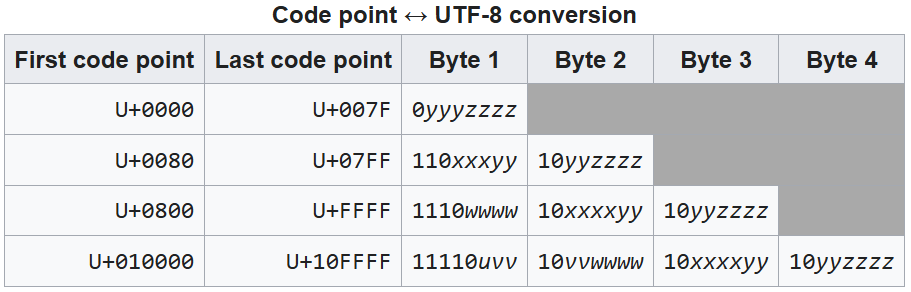

*Figure: Code point ↔ UTF-8 conversion. Image taken from [Wikipedia: UTF-8](https://en.wikipedia.org/wiki/UTF-8).*

</div>

The byte value **129** is **`10000001` in binary**. Its leading bits, `10`, identify it as a **continuation byte**, as shown in the table's Byte 2, Byte 3, and Byte 4 columns. It must follow the start of a multi-byte sequence, so it is invalid on its own. With `errors="replace"`, `decode([129])` therefore returns `"�"`.

The same byte is valid in the right sequence: `decode([195, 129])` returns `"Á"`. Here, `195` (`11000011`) starts a two-byte sequence and `129` (`10000001`) completes it.

Encoding --> we have a text string and want to convert it to integer tokens.

In [14]:
def encode(text):
  # Convert text to token IDs using the rules learned during training.
  tokens = list(text.encode("utf-8"))
  while len(tokens) >= 2:
    stats = get_stats(tokens)
    # Look at the neighboring token pairs in the text and choose the one whose merge rule was learned first during training.
    token_pair = min(stats, key=lambda p: merges.get(p, float("inf")))
    if token_pair not in merges:
      break # No learned rule matches any remaining pair.
    token_id = merges[token_pair]
    tokens = merge(tokens, token_pair, token_id)
  return tokens

print(encode(""))

[]


The `encode(text)` function **turns a Python string into a list of token IDs using the rules learned during training**. It starts with UTF-8 bytes and repeatedly applies eligible rules from `merges` in their learned priority order.

Encoding uses the existing vocabulary: the `merges` dictionary stays fixed, and the function returns the IDs needed to represent this particular text.

Here is how the function works:

1. **`tokens = list(text.encode("utf-8"))`** converts the string to bytes, then turns those bytes into a list of integers. For example, `"ababab"` becomes `[97, 98, 97, 98, 97, 98]`. These values are our base token IDs, from `0` to `255`. A character can contribute several bytes: `"é"` starts as `[195, 169]`.

2. **`while len(tokens) >= 2`** continues while there are at least two tokens available to form a pair.

3. **`stats = get_stats(tokens)`** finds the neighboring pairs in the current sequence. For encoding, we use the dictionary's keys to find which pairs are present; their counts do not determine which rule to apply.

4. **`token_pair = min(stats, key=lambda p: merges.get(p, float("inf")))`** selects the present pair with the earliest learned merge rule. This line is unpacked below.

5. **`if token_pair not in merges: break`** stops when none of the present pairs has a learned rule. Every learned rule has a finite priority, so it would have been selected ahead of an unknown pair.

6. **`token_id = merges[token_pair]`** looks up the existing token ID for the chosen pair. **`tokens = merge(tokens, token_pair, token_id)`** replaces its non-overlapping occurrences with that ID. The next iteration examines the updated sequence, including any newly formed pairs.

7. **`return tokens`** returns the final list of token IDs.

For the main idea, read the selection line as:

> Look at the neighboring token pairs in the text and choose the one whose merge rule was learned first during training.

The key to understanding the selection line is that **smaller new token IDs correspond to earlier training steps** in this notebook: `256` was learned first, then `257`, and so on.

```python
token_pair = min(stats, key=lambda p: merges.get(p, float("inf")))
```

- Iterating over `stats` gives its keys, which are the pairs currently present.
- `lambda p: ...` is a small function that computes a priority for each candidate pair `p`.
- `merges.get(p, float("inf"))` returns the learned token ID if the pair has a rule, or positive infinity if it does not. Infinity sorts after every finite token ID.
- `min(...)` chooses the pair with the smallest priority. For example, an available rule producing token `256` takes priority over one producing token `270`, even if the second pair appears more often in this input.

During **training**, pair frequency determines the next rule to learn. During **encoding**, the learned order determines which available rule to apply. Preserving this order gives new text a consistent tokenization based on the trained tokenizer.

Using the same illustrative rules as before:

```python
merges = {
    (97, 98): 256,    # a + b -> ab
    (256, 256): 257,  # ab + ab -> abab
}
```

encoding `"ababab"` proceeds like this:

| Current token sequence | Rule applied | Result |
| --- | --- | --- |
| `[97, 98, 97, 98, 97, 98]` | `(97, 98) → 256` | `[256, 256, 256]` |
| `[256, 256, 256]` | `(256, 256) → 257` | `[257, 256]` |
| `[257, 256]` | No rule for `(257, 256)`; stop | `[257, 256]` |

So `encode("ababab")` returns `[257, 256]` with these illustrative rules. The actual IDs depend on the rules learned from our training text.

**Why does `print(encode(""))` display `[]`?** An empty string produces an empty byte list. The `while` condition is false immediately, so the function returns that empty list.

Together, the two data structures support the full round trip: `encode` uses **`merges`** to combine token IDs, and `decode` uses **`vocab`** to recover their bytes and convert them back to text. With matching rules and vocabulary, `decode(encode("ababab"))` returns `"ababab"`.

In [15]:
# Encode and decode a new sentence to recover the original text.
print(decode(encode("Let's see if we get the same string back after the decode step.")))

Let's see if we get the same string back after the decode step.


In [16]:
# Check that the entire training text survives the round trip.
decoded_text = decode(encode(extended_text))
print("Success" if decoded_text == extended_text else "Failure")

Success
